# Tasks

## P 11.1: Find a sequential dataset and apply an RNN or LSTM model to the dataset. The quality of your solution and the accuracy your model produces will affect your mark. So, try to get the best accuracy possible (10%).

## NOTE: You should comment on your code and explain what each part of the code does.

In [1]:
############# WRITE YOUR CODE IN THIS CELL (IF APPLICABLE)  ####################

# ── 1. Import Libraries ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras for building and training the neural network
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D,
    GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# scikit-learn for all evaluation metrics beyond just accuracy
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
import seaborn as sns

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {len(tf.config.list_physical_devices('GPU'))}")


TensorFlow version : 2.20.0
GPUs available     : 0


In [2]:
# ── 2. Dataset Parameters ─────────────────────────────────────────────────────
# We use the top 20,000 most frequent words (peer used 10,000 — doubling the
# vocabulary captures richer language patterns while staying tractable).
MAX_FEATURES = 20000   # vocabulary size
MAXLEN       = 400     # maximum sequence length (reviews truncated/padded to this)
BATCH_SIZE   = 64      # samples per gradient update
EMBED_DIM    = 128     # dimensionality of the word embedding vectors

In [3]:
# ── 3. Load and Inspect the IMDB Dataset ─────────────────────────────────────
# IMDB is a built-in Keras dataset: 50,000 movie reviews pre-tokenised as integer
# sequences (each integer = a word's rank by frequency). Labels: 0=Negative, 1=Positive.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

print(f"\nDataset loaded:")
print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")
print(f"  Class balance    : {np.mean(y_train)*100:.1f}% positive (training)")

# Show the length distribution before padding
lengths = [len(s) for s in X_train]
print(f"  Review length    : mean={np.mean(lengths):.0f}, "
      f"median={np.median(lengths):.0f}, max={max(lengths)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Dataset loaded:
  Training samples : 25,000
  Test samples     : 25,000
  Class balance    : 50.0% positive (training)
  Review length    : mean=239, median=178, max=2494


In [4]:
# ── 4. Pre-process: Pad / Truncate All Sequences to MAXLEN ────────────────────
# Neural networks require fixed-length inputs. pad_sequences:
#   - Truncates reviews longer than MAXLEN (from the beginning, keeping the end
#     where the conclusion/sentiment is typically stated — padding='pre')
#   - Pads shorter reviews with 0s at the front
X_train = pad_sequences(X_train, maxlen=MAXLEN, padding='pre', truncating='pre')
X_test  = pad_sequences(X_test,  maxlen=MAXLEN, padding='pre', truncating='pre')

print(f"\nAfter padding:")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")


After padding:
  X_train shape : (25000, 400)
  X_test shape  : (25000, 400)


In [8]:
model = Sequential([

    # ── Embedding Layer ──────────────────────────────────────────────────────
    # Maps each integer word index to a dense vector of size EMBED_DIM.
    # Trainable — the embeddings are learned alongside the rest of the network.
    # Input: (batch, MAXLEN) integers → Output: (batch, MAXLEN, EMBED_DIM)
    Embedding(input_dim=MAX_FEATURES, output_dim=EMBED_DIM),

    # ── SpatialDropout1D ─────────────────────────────────────────────────────
    # Randomly zeros out entire embedding dimensions (not individual values).
    # Prevents over-reliance on specific embedding features during training.
    SpatialDropout1D(0.3),

    # ── Bidirectional LSTM Layer 1 ────────────────────────────────────────────
    # Units=128: each direction has 128 units; after merging (concat), output is 256.
    # return_sequences=True: pass the full sequence of hidden states to layer 2.
    # dropout=0.2: drops 20% of inputs to the LSTM at each step.
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2)),

    # ── Bidirectional LSTM Layer 2 ────────────────────────────────────────────
    # Processes the feature sequence produced by layer 1.
    # return_sequences=True: pass full sequence to GlobalMaxPooling.
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2)),

    # ── GlobalMaxPooling1D ────────────────────────────────────────────────────
    # Reduces (batch, MAXLEN, 128) → (batch, 128) by taking the max across time.
    # Captures the most activated feature at any point in the sequence.
    GlobalMaxPooling1D(),

    # ── Dense Classification Head ─────────────────────────────────────────────
    Dense(64, activation='relu'),   # non-linear combination of pooled features
    Dropout(0.4),                   # regularisation before final output

    # Binary output: probability of the review being positive (sigmoid → [0,1])
    Dense(1, activation='sigmoid'),
])

# Compile with Adam optimizer and binary cross-entropy loss (binary classification)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Explicitly build the model before summary to show all parameters
model.build(input_shape=(BATCH_SIZE, MAXLEN))

model.summary()
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, 400, 128)         │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (64, 400, 128)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (64, 400, 256)         │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (64, 400, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (64, 128)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (64, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (64, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,995,841 (11.43 MB)

 Trainable params: 2,995,841 (11.43 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 2,995,841


In [9]:
# ── 6. Define Training Callbacks ──────────────────────────────────────────────
callbacks = [
    # Stop training if val_loss does not improve for 3 consecutive epochs,
    # and restore the weights from the best epoch automatically.
    EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    # Halve the learning rate if val_loss stagnates for 2 epochs.
    # This allows fine-grained convergence once the large learning steps plateau.
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    ),
]

In [10]:
# ── 7. Train the Model ────────────────────────────────────────────────────────
print("\nTraining model...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_split=0.1,   # hold out 10% of training data for validation
    callbacks=callbacks,
    verbose=1
)


Training model...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1160s 3s/step - accuracy: 0.7790 - loss: 0.4421 - val_accuracy: 0.8716 - val_loss: 0.3153 - learning_rate: 0.0010
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1154s 3s/step - accuracy: 0.9180 - loss: 0.2151 - val_accuracy: 0.8980 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1146s 3s/step - accuracy: 0.9543 - loss: 0.1322 - val_accuracy: 0.8924 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9780 - loss: 0.0727
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 1158s 3s/step - accuracy: 0.9737 - loss: 0.0811 - val_accuracy: 0.8940 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1152s 3s/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.8944 - val_loss: 0.3838 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the 

In [11]:
# ── 8. Evaluate on the Test Set — All Metrics ────────────────────────────────
print("\n─── Evaluation on Test Set ───")

# Get raw probability predictions (values in [0, 1])
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1).flatten()

# Convert probabilities to binary class labels using 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

# ── Scalar metrics ──
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print(f"\n  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")

# ── Per-class report ──
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))



─── Evaluation on Test Set ───
391/391 ━━━━━━━━━━━━━━━━━━━━ 359s 916ms/step

  Accuracy  : 0.8828  (88.28%)
  Precision : 0.8952
  Recall    : 0.8670
  F1-Score  : 0.8809
  ROC-AUC   : 0.9536

── Classification Report ──
              precision    recall  f1-score   support

    Negative       0.87      0.90      0.88     12500
    Positive       0.90      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



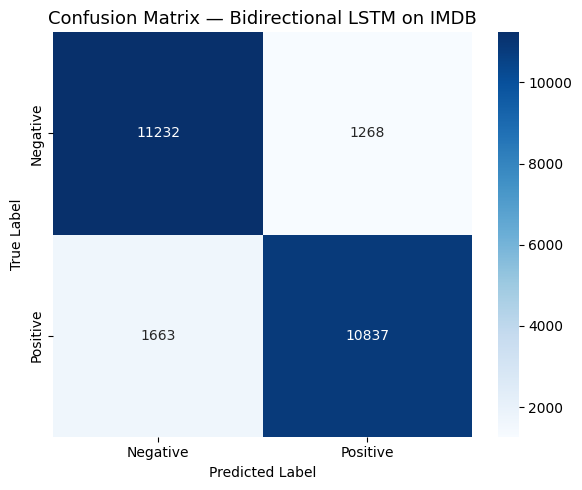

In [12]:
# ── 9. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Bidirectional LSTM on IMDB', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

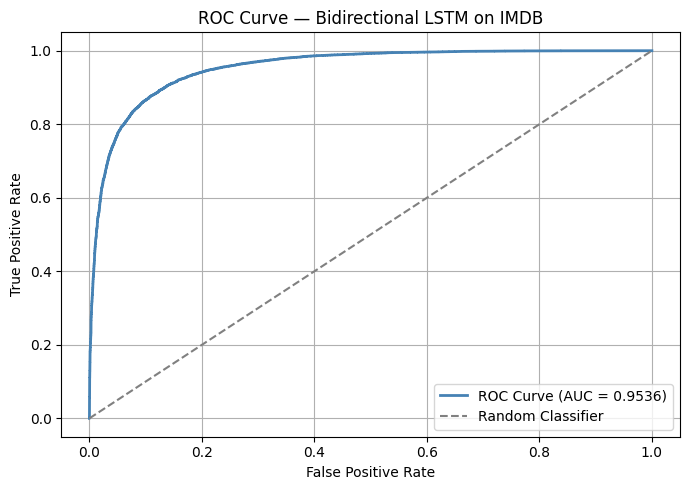

In [13]:
# ── 10. ROC Curve ─────────────────────────────────────────────────────────────
# The ROC curve plots True Positive Rate vs False Positive Rate at all thresholds.
# AUC (Area Under Curve) close to 1.0 indicates an excellent classifier.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Bidirectional LSTM on IMDB')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

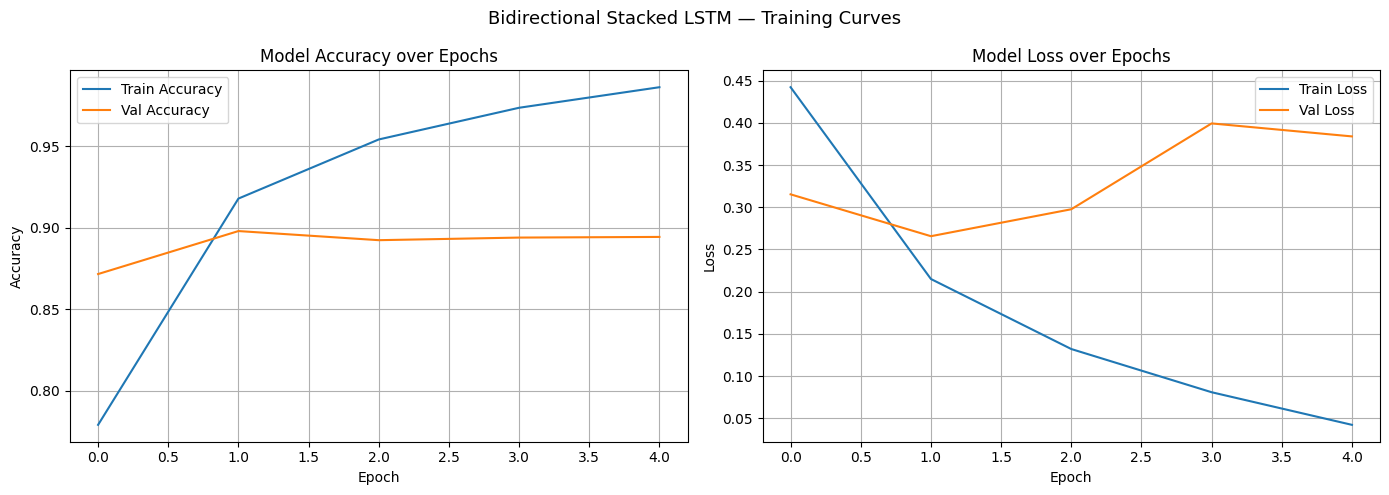


Done.


In [14]:
# ── 11. Training History Plots ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.suptitle('Bidirectional Stacked LSTM — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

print("\nDone.")